In [1]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [2]:
customers = pd.read_csv('olist_customers_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')

print('DataFrames successfully loaded!')

DataFrames successfully loaded!


In [3]:
# Initialize DuckDB connection
con = duckdb.connect()

# SQL query to unbundle and restructure the relational e-commerce tables
query = """
SELECT

-- OPERATIONAL BLOCK: ORDER METADATA AND LOGISTICS TIMESTAMPS
o.order_id,
o.customer_id,
o.order_status,
o.order_purchase_timestamp,
o.order_delivered_customer_date,
o.order_estimated_delivery_date,

-- FINANCIAL & COMMERCIAL BLOCK: PRODUCT/SELLER IDS, REVENUE, AND FREIGHT COST
i.product_id,
i.seller_id,
i.price,
i.freight_value,

-- PHYSICAL CHARACTERISTICS BLOCK (LOGISTICS): PACKAGE CATEGORY, WEIGHT, AND DIMENSIONS
p.product_category_name,
p.product_weight_g,
p.product_length_cm,
p.product_height_cm,
p.product_width_cm,

-- GEOGRAPHICAL BLOCK: REGIONAL REGISTRATION FOR DESTINATION (BUYER) AND ORIGIN (SELLER)
c.customer_state,
s.seller_state

FROM 'olist_order_items_dataset.csv' AS i

-- JOINING WITH ORDERS TO EXTRACT TIME-BASED MILESTONES
INNER JOIN 'olist_orders_dataset.csv' AS o
ON i.order_id = o.order_id

-- JOINING WITH PRODUCTS TO CAPTURE PHYSICAL ATTRIBUTES AND METRICS
INNER JOIN 'olist_products_dataset.csv' AS p
ON i.product_id = p.product_id

-- JOINING WITH CUSTOMERS TO MAP TARGET DESTINATION REGION
INNER JOIN 'olist_customers_dataset.csv' AS c
ON o.customer_id = c.customer_id

-- JOINING WITH SELLERS TO MAP ORIGIN DISPATCH REGION
INNER JOIN 'olist_sellers_dataset.csv' AS s
ON i.seller_id = s.seller_id;
"""

# Execute the pipeline query and convert the dataset directly into a Pandas DataFrame
df = con.execute(query).df()

# Verify the query ingestion result
print(f'DataFrame successfully generated via SQL: {df.shape[0]} rows')
df.head()

DataFrame successfully generated via SQL: 112650 rows


,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,product_id,seller_id,price,freight_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_state,seller_state
0,8426a61c687c38a2fb35080413ec9eb4,c3b836aea9b06d84b1b9d38b41f137e1,delivered,2017-10-25 22:52:31,2017-10-27 15:18:00,2017-11-07,110adb18eeba9a0984478ee3c9302e16,080199a181c46c657dc5aa235411be3b,179.49,9.45,automotivo,550,16,21,18,SP,SP
1,8426c20fc1f780e653122762baef129e,e432b25f546d2cc6643c25d070e75c62,delivered,2017-12-16 00:58:56,2017-12-27 21:18:39,2018-01-11,59ebd2c07d59483d0855b5b3d5e18728,ea8482cd71df3c1969d7b9473ff13abc,27.99,11.85,telefonia,300,17,4,12,SP,SP
2,84270b9b2f185170b4b29b448ef3a0cc,b1fb921da8da31f114b8f25530967fe7,delivered,2017-06-19 20:32:27,2017-06-28 15:32:55,2017-07-07,777d2e438a1b645f3aec9bd57e92672c,4a3ca9315b744ce9f8e9374361493884,69.90,12.83,cama_mesa_banho,950,45,15,35,SP,SP
3,84275d513f92f95d3e62865feeaab895,3248720a7617d01317ab868c2bb3676a,delivered,2018-01-14 11:32:28,2018-01-18 22:58:04,2018-02-09,2028bf1b01cafb2d2b1901fca4083222,cc419e0650a3c5ba77189a1882b7556a,56.99,14.15,perfumaria,250,20,8,21,PR,SP
4,842785266c32e96b693fa76cf473a88f,fd06144f27bb7cd0a11db676d656a9c6,delivered,2018-01-21 13:29:20,2018-01-26 18:06:36,2018-02-06,3308e7337d30a51ac18fa4e9e72b310c,ea8482cd71df3c1969d7b9473ff13abc,27.99,7.78,telefonia,350,17,4,12,SP,SP


In [4]:
# FEATURE ENGINEERING & MISSING VALUES TREATMENT

# 1. Ensure all date columns are in the correct datetime format
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Filter only 'delivered' orders since cancelled or unavailable orders don't have final delivery dates
df_model = df[df['order_status'] == 'delivered'].copy()

# Impute missing values in physical and financial features using the median to avoid dropping rows
columns_to_impute = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'freight_value', 'price']
for col in columns_to_impute:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(df_model[col].median())

# Drop remaining rows without a valid delivery timestamp (system recording anomalies)
df_model = df_model.dropna(subset=['order_delivered_customer_date'])

# 2. Define the TARGET variable (is_late): 1 = delayed, 0 = delivered on time/early
# Calculate the day delta: Actual Delivery Date - Estimated Delivery Date
df_model['days_delivery_diff'] = (df_model['order_delivered_customer_date'] - df_model['order_estimated_delivery_date']).dt.days
df_model['is_late'] = (df_model['days_delivery_diff'] > 0).astype(int)
df_model['is_same_state'] = (df_model['customer_state'] == df_model['seller_state']).astype(int)

# Logistic features engineering: package volume and freight-to-price ratio
df_model['product_volume_cm3'] = df_model['product_length_cm'] * df_model['product_height_cm'] * df_model['product_width_cm']
df_model['freight_ratio'] = df_model['freight_value'] / (df_model['price'] + 0.1)

# Apply log transformation to smooth highly skewed numerical distributions (outliers)
df_model['log_weight'] = np.log1p(df_model['product_weight_g'])
df_model['log_volume'] = np.log1p(df_model['product_volume_cm3'])
df_model['log_freight'] = np.log1p(df_model['freight_value'])

# 3. Create a simplified distance feature
# 1 = Local delivery (same state), 0 = Interstate delivery (different states)
df_model['is_same_state'] = (df_model['customer_state'] == df_model['seller_state']).astype(int)

# Final validation check for remaining missing values
print('Missing values per column after treatment:')
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

print('\n---')
print(f'DataFrame ready for analysis: {df_model.shape[0]} rows')
print(f"Base delay rate: {df_model['is_late'].value_counts(normalize=True)[1]:.2%}")

Missing values per column after treatment:
product_category_name    1537
dtype: int64

---
DataFrame ready for analysis: 110189 rows
Base delay rate: 6.59%


Local delivery delay rate: 4.45%
Interstate delivery delay rate: 7.81%


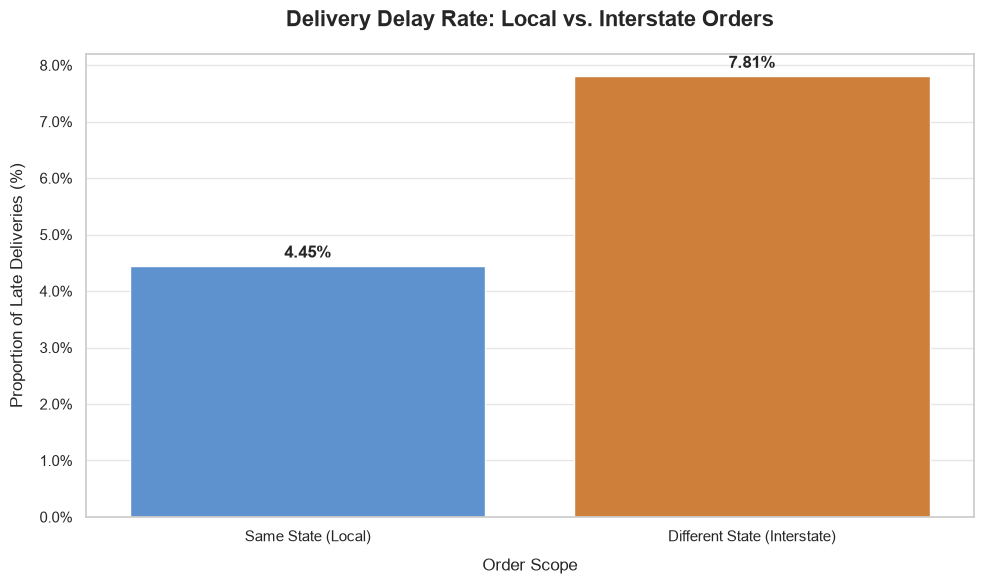

In [5]:
# DATA VISUALIZATION (EDA): DELAY RATE COMPARISON

# Configure the visual style
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))

# Create a copy for plotting and map binary values to human-readable strings
df_plot = df_model.copy()
df_plot['Shipping Type'] = df_plot['is_same_state'].map({1: 'Same State (Local)', 0: 'Different State (Interstate)'})

# Calculate exact delay rates per category to print in the console
rates = df_plot.groupby('Shipping Type')['is_late'].mean() * 100
print(f"Local delivery delay rate: {rates['Same State (Local)']:.2f}%")
print(f"Interstate delivery delay rate: {rates['Different State (Interstate)']:.2f}%")

# Plot the delay rate comparison bar chart
ax = sns.barplot(
    x='Shipping Type',
    y='is_late',
    data=df_plot,
    hue='Shipping Type',
    legend=False,
    errorbar=None,
    palette=['#4a90e2', '#e67e22']
)

# Set descriptive chart titles and labels
plt.title('Delivery Delay Rate: Local vs. Interstate Orders', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Order Scope', fontsize=12, labelpad=10)
plt.ylabel('Proportion of Late Deliveries (%)', fontsize=12, labelpad=10)

# Format the Y-axis numbers as percentages
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# Dynamically annotate the exact percentages on top of each bar
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
# MACHINE LEARNING IMPLEMENTATION: RANDOM FOREST CLASSIFIER

# 1. Feature and Target selection
features = [
    'price', 'log_freight', 'is_same_state',
    'log_weight', 'log_volume', 'freight_ratio'
]
X = df_model[features]
y = df_model['is_late']

# 2. Train/Test Split (80/20) with stratification to handle class imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Model Training (Non-linear ensemble learning approach)
# Max depth is capped at 10 to protect the model against overfitting
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)

# 4. Generating class predictions and raw probability scores
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

# 5. Displaying comprehensive evaluation metrics for portfolio review
print("\n--- Model Performance Report ---")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Metric: {roc_auc_score(y_test, y_proba_rf):.4f}")


--- Model Performance Report ---
              precision    recall  f1-score   support

           0       0.95      0.52      0.67     20585
           1       0.09      0.64      0.15      1453

    accuracy                           0.53     22038
   macro avg       0.52      0.58      0.41     22038
weighted avg       0.90      0.53      0.64     22038

ROC-AUC Metric: 0.6248


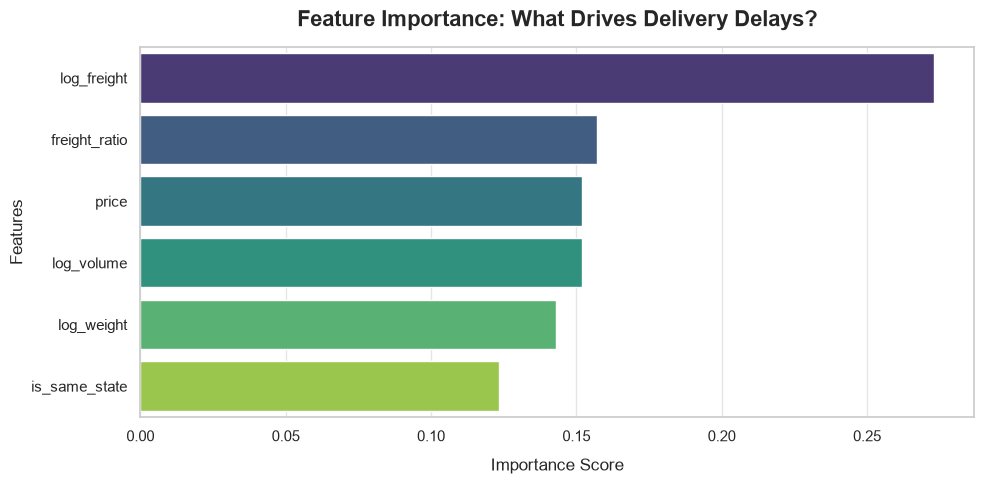

Feature Importance Ranking:
      Feature  Importance
  log_freight    0.273130
freight_ratio    0.156938
        price    0.151829
   log_volume    0.151795
   log_weight    0.143075
is_same_state    0.123233


In [7]:
# FEATURE IMPORTANCE EXTRACTION & VISUALIZATION

# Extract feature coefficients/importances from the trained Random Forest model
importances = model_rf.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Configure the visualization layout and aesthetics
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 5))

# Plot the feature importances as a horizontal bar chart
ax = sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_imp_df,
    hue='Feature',
    legend=False,
    palette='viridis'
)

# Set descriptive chart titles
plt.title('Feature Importance: What Drives Delivery Delays?', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12, labelpad=10)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# Print the exact scoring data structure for technical evaluation
print('Feature Importance Ranking:')
print(feature_imp_df.to_string(index=False))